# Data 6 Summer 2026: Intro to Visualizations

In [53]:
from datascience import *
import numpy as np
#Use this to show the visualization in line for us :)
%matplotlib inline 

import matplotlib.pyplot as plots #Our new library, matplotlib
plots.style.use('fivethirtyeight') #Optional, but it's a commonly used, pre-determined set of colors https://matplotlib.org/stable/gallery/style_sheets/fivethirtyeight.html

## Task: Analyze Age Distribution for Residents of North Carolina

### Data cleaning

Data "cleaning" is a broad term that refers to making our data more managable. We keep the values we want and get rid of the ones we don't need for our analysis.

In [54]:
full = Table.read_table('data/nc-est2019-agesex-res.csv')
full

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323
0,5,4056858,4056872,4064521,4087054,4131049,4121876,4004576,4017589,4035033,4003452,4008443,4028281
0,6,4066381,4066412,4072904,4074531,4096631,4141126,4133372,4017388,4031568,4048018,4014057,4017227
0,7,4030579,4030594,4042990,4082821,4084175,4106756,4152666,4145872,4030888,4044139,4058370,4022319
0,8,4046486,4046497,4025501,4052773,4092559,4094513,4118349,4165033,4158848,4042924,4054236,4066194
0,9,4148353,4148369,4125312,4035319,4062726,4103052,4106068,4130887,4177895,4170813,4053179,4061874


In [6]:
# Keep only the columns we care about
partial = full.select('SEX', 'AGE', 'POPESTIMATE2019')
partial

SEX,AGE,POPESTIMATE2019
0,0,3783052
0,1,3829599
0,2,3922044
0,3,3998665
0,4,4043323
0,5,4028281
0,6,4017227
0,7,4022319
0,8,4066194
0,9,4061874


In [55]:
# Make things easier to read
us_pop_2019 = partial.relabeled(2, '2019')
us_pop_2019.show(5)

SEX,AGE,2019
0,0,3783052
0,1,3829599
0,2,3922044
0,3,3998665
0,4,4043323


### Some plots for numerical attributes

**Task**: Plot the total population (in millions) as each age increases:

> The SEX column contains numeric codes: 1 for male, 2 for female, and 0 for the total.

> The AGE column contains ages in completed years. The special value 999 represents the entire population regardless of age, and 100 represents “100 or more”. 

In [56]:
total_below_999 = us_pop_2019.where('AGE',are.below(999)).where('SEX', 0) #Filter for all AGE < 999 and SEX == 0
total_below_999
total_below_999 = total_below_999.with_columns('Population (in millions)', total_below_999.column('2019')/1e6) #Create a new column that represents columns in millions
total_below_999

SEX,AGE,2019,Population (in millions)
0,0,3783052,3.78305
0,1,3829599,3.8296
0,2,3922044,3.92204
0,3,3998665,3.99866
0,4,4043323,4.04332
0,5,4028281,4.02828
0,6,4017227,4.01723
0,7,4022319,4.02232
0,8,4066194,4.06619
0,9,4061874,4.06187


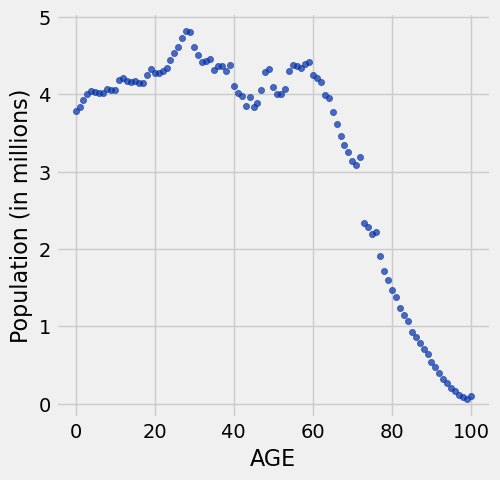

In [57]:
total_below_999.scatter('AGE', 'Population (in millions)')

Text(0.5, 1.0, 'Population Graph')

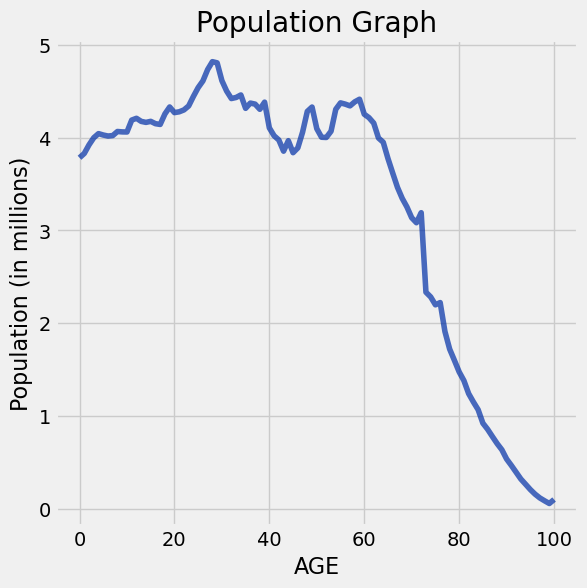

In [62]:
total_below_999.plot('AGE', 'Population (in millions)')

_____

**Discussion [1 min]:** What are some things you notice from the below visualization? (1 min)

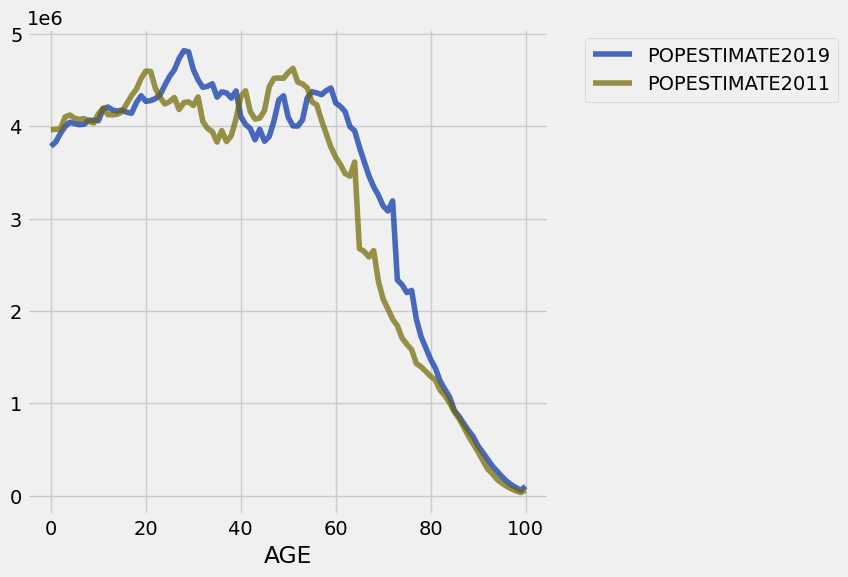

In [59]:
full.select('AGE', 'SEX', 
            'POPESTIMATE2019', 'POPESTIMATE2011').where('AGE',
                                                        are.below(999)).where('SEX',
                                                                              0).drop('SEX').plot('AGE')


______

## Actors

In [60]:
# Actors and their highest grossing movies
actors = Table.read_table('data/actors.csv')
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


---

  ### Line plot? Or scatter plot?
    
**Task:** Plot the relationship between the number of movies cast and average salary per movie among famous Hollywood actors.

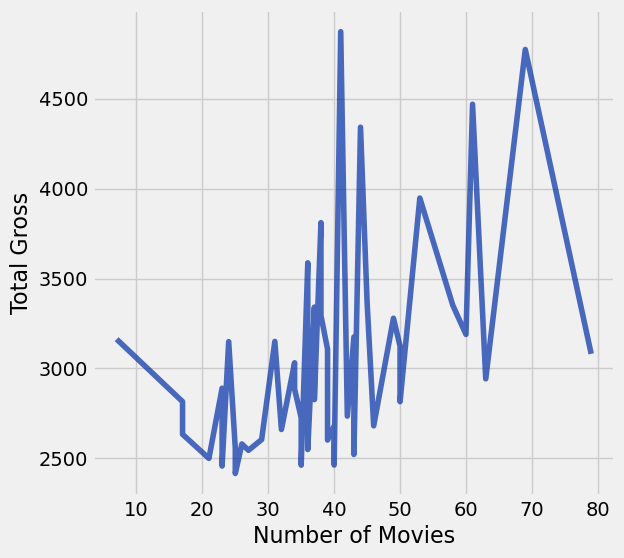

In [24]:
actors.plot('Number of Movies', 'Total Gross')

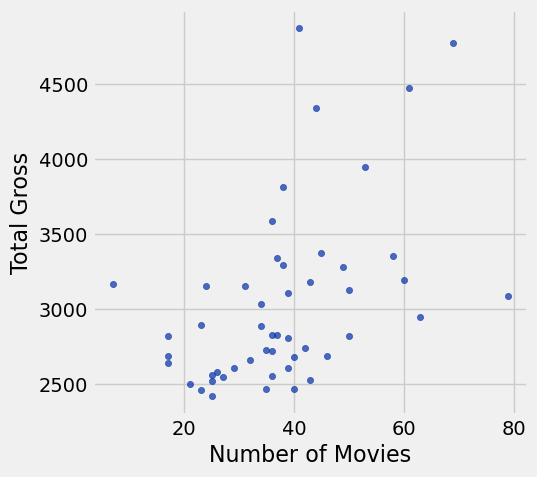

In [26]:
actors.scatter('Number of Movies', 'Total Gross')

#### Remember: Investigate anomalies!!

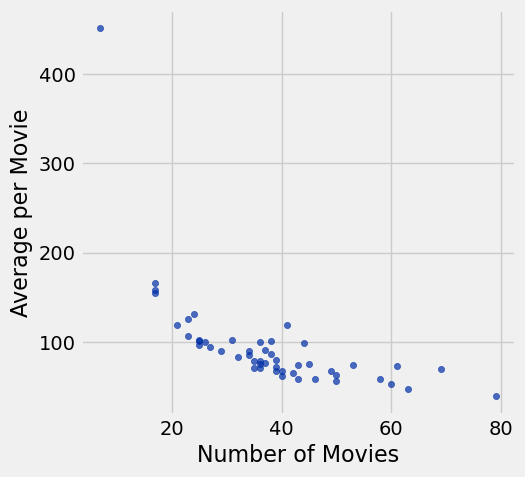

In [27]:
actors.scatter('Number of Movies', 'Average per Movie')

In [28]:
actors.where('Average per Movie', are.above(400))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


## Bar Charts

### Example 1: Counts of categorical variable

In [49]:
# Highest grossing movies as of 2017
top_movies = Table.read_table('data/top_movies_2017.csv')
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


#### **Task**: Visualize the number of movies released by each studio.

In [50]:
#Hint, how do we GROUP the the number of movies by studio?
studio_counts...

SyntaxError: invalid syntax (3727139140.py, line 2)

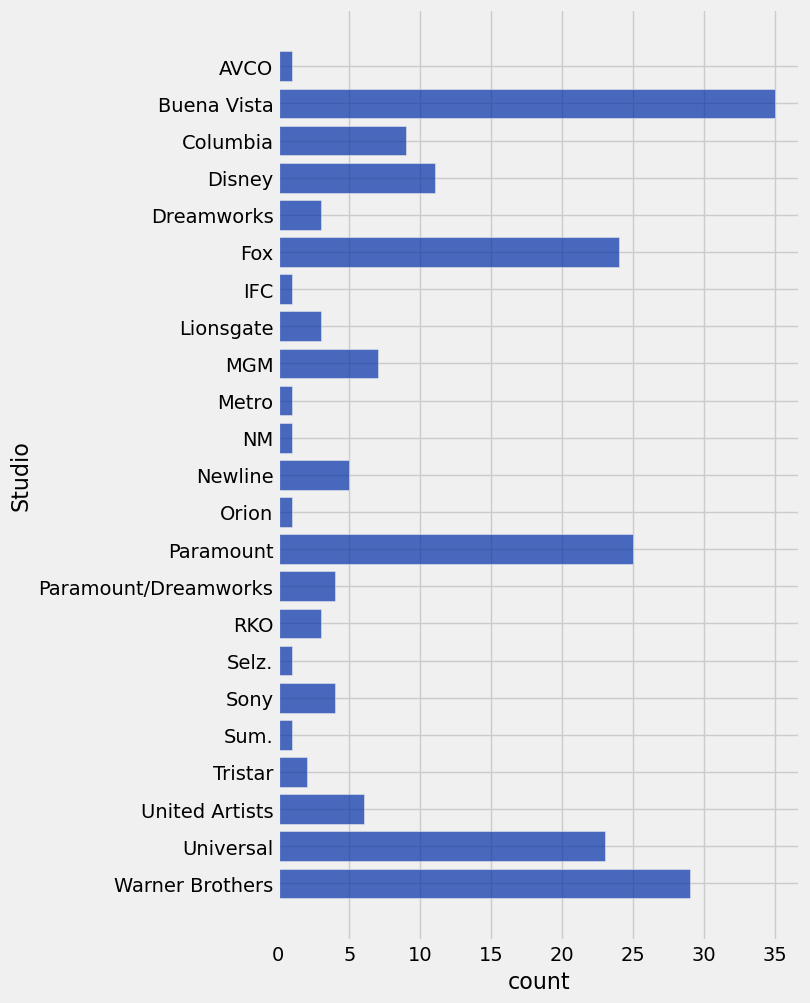

In [51]:
studio_counts.barh('Studio')

**Discussion [30 sec]:** How might this plot be improved to show a clearer message about the data? 

In [35]:
#Use "Data Cleaning" To Show a Clearer Data Viz!

---

### Example 2: Categorical x Numerical

#### **Task**: Visualize the top 10 highest adjusted grossing movies by US dollars (in millions).

In [36]:
top10_adjusted = top_movies.take(np.arange(10))
top10_adjusted #Is this dataset how we want it to be sorted? Don't assume it will always be sorted as we want!

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


Convert to millions of dollars for readability

In [37]:
millions = np.round(top10_adjusted.column('Gross (Adjusted)') / 1000000, 3)
top10_adjusted = top10_adjusted.with_column('Millions', millions)
top10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year,Millions
Gone with the Wind,MGM,198676459,1796176700,1939,1796.18
Star Wars,Fox,460998007,1583483200,1977,1583.48
The Sound of Music,Fox,158671368,1266072700,1965,1266.07
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982,1261.09
Titanic,Paramount,658672302,1204368000,1997,1204.37
The Ten Commandments,Paramount,65500000,1164590000,1956,1164.59
Jaws,Universal,260000000,1138620700,1975,1138.62
Doctor Zhivago,MGM,111721910,1103564200,1965,1103.56
The Exorcist,Warner Brothers,232906145,983226600,1973,983.227
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937,969.01


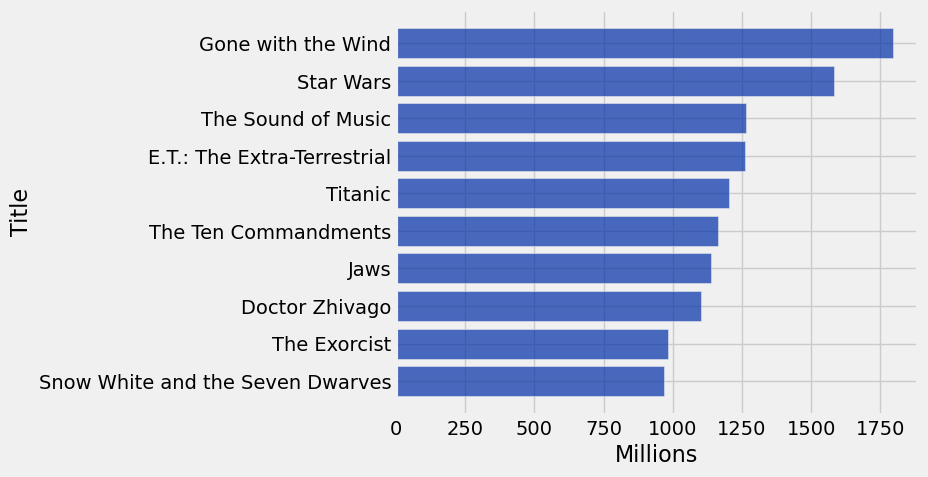

In [38]:
top10_adjusted.barh('Title', 'Millions')

### Good visualization practices

We can (and should) clearly define the labels for our visualization and our x/y axes (if we have them).

Text(0, 0.5, 'Movie Title')

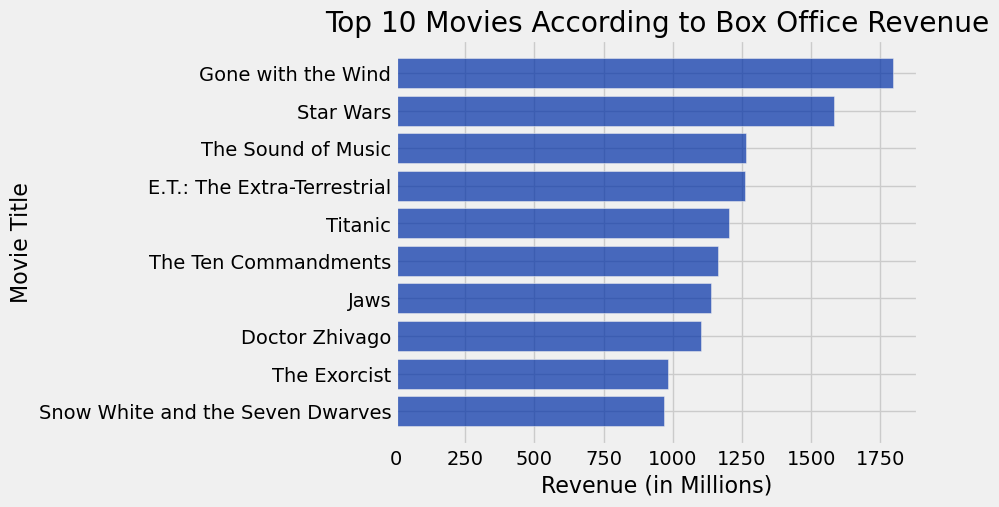

In [67]:
top10_adjusted.barh('Title', 'Millions')
#You have to declare the title, xlabel, and ylabel in each cell you run
plots.title("Top 10 Movies According to Box Office Revenue")
plots.xlabel("Revenue (in Millions)")
plots.ylabel("Movie Title")